In [1]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00


In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from itertools import product
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from transformers import T5Tokenizer, T5EncoderModel
from Bio import SeqIO
import warnings

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Overlap between training and validation sets**

In [ ]:
# ── 1. Load sequences ──────────────────────────────────────────────────────────

def load_fasta(path):
    return {rec.id: str(rec.seq).upper() for rec in SeqIO.parse(path, "fasta")}

#train1_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amppeppy_train_pos.fasta")
#train2_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amppeppy_train_neg.fasta")

#train1_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/ampscan_train_pos.fasta")
#train2_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/ampscan_train_neg.fasta")

#train1_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amplify_balanced_train_pos.fasta")
#train2_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amplify_balanced_train_neg.fasta")

#train1_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amplify_balanced_train_pos.fasta")
#train2_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amplify_imbalanced_train_neg.fasta")

train1_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/pepnet_train_pos.fasta")
train2_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/pepnet_train_neg.fasta")

val1_seqs    = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/validation/grampa_cdhit.fasta")
val2_seqs    = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/validation/non-grampa_cdhit.fasta")

In [ ]:
# ── 2. Identify exact matches (train vs val) ───────────────────────────────────

def find_shared(train: dict, val: dict) -> set:
    """Returns val IDs whose sequence appears verbatim in train."""
    train_seqset = set(train.values())
    return {vid for vid, vseq in val.items() if vseq in train_seqset}

shared1 = find_shared(train1_seqs, val1_seqs)
shared2 = find_shared(train2_seqs, val2_seqs)

print(f"GRAMPA sequences shared with train1:     {len(shared1)}/{len(val1_seqs)}")
print(f"non-GRAMPA sequences shared with train2: {len(shared2)}/{len(val2_seqs)}")

GRAMPA sequences shared with train1:     703/1731
non-GRAMPA sequences shared with train2: 579/1185


**Peptide Embeddings**

In [ ]:
# ── 3. Load ProstT5 ────────────────────────────────────────────────────────────

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("Rostlab/ProstT5", do_lower_case=False)
model     = T5EncoderModel.from_pretrained("Rostlab/ProstT5")
model     = model.to(device).eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

In [ ]:
# ── 4. Embed + save sequences ──────────────────────────────────────────────────

def embed_and_save(seqs: dict, save_path: str, batch_size=16) -> tuple[list, np.ndarray]:
    if os.path.exists(save_path):
        print(f"  Loading cached embeddings from {save_path}")
        return load_embeddings(save_path)
    ids, raw = list(seqs.keys()), list(seqs.values())
    embs = []
    for i in range(0, len(raw), batch_size):
        batch     = raw[i : i + batch_size]
        formatted = ["<AA2fold> " + " ".join(list(s)) for s in batch]
        enc = tokenizer(formatted, add_special_tokens=True,
                        padding="longest", return_tensors="pt")
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(1) / mask.sum(1)
        embs.append(pooled.cpu().float().numpy())
        print(f"  Embedded {min(i + batch_size, len(raw))}/{len(raw)}")
    embeddings = np.vstack(embs)
    np.savez(save_path, ids=np.array(ids), embeddings=embeddings)
    print(f"  Saved → {save_path}")
    return ids, embeddings

def load_embeddings(path: str) -> tuple[list, np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return data["ids"].tolist(), data["embeddings"]

def save_embeddings(ids: list, embeddings: np.ndarray, path: str) -> None:
    np.savez(path, ids=np.array(ids), embeddings=embeddings)
    print(f"Saved {len(ids)} embeddings → {path}")

BASE = "/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/embeddings"

#print("Embedding val1...");   val1_ids,   val1_emb   = embed_and_save(val1_seqs,   f"{BASE}/embeddings_grampa.npz")
#print("Embedding val2...");   val2_ids,   val2_emb   = embed_and_save(val2_seqs,   f"{BASE}/embeddings_non_grampa.npz")
print("Embedding train1..."); train1_ids, train1_emb = embed_and_save(train1_seqs, f"{BASE}/embeddings_pepnet_train1.npz")
print("Embedding train2..."); train2_ids, train2_emb = embed_and_save(train2_seqs, f"{BASE}/embeddings_pepnet_train2.npz")

Embedding train1...
  Embedded 16/3338
  Embedded 32/3338
  Embedded 48/3338
  Embedded 64/3338
  Embedded 80/3338
  Embedded 96/3338
  Embedded 112/3338
  Embedded 128/3338
  Embedded 144/3338
  Embedded 160/3338
  Embedded 176/3338
  Embedded 192/3338
  Embedded 208/3338
  Embedded 224/3338
  Embedded 240/3338
  Embedded 256/3338
  Embedded 272/3338
  Embedded 288/3338
  Embedded 304/3338
  Embedded 320/3338
  Embedded 336/3338
  Embedded 352/3338
  Embedded 368/3338
  Embedded 384/3338
  Embedded 400/3338
  Embedded 416/3338
  Embedded 432/3338
  Embedded 448/3338
  Embedded 464/3338
  Embedded 480/3338
  Embedded 496/3338
  Embedded 512/3338
  Embedded 528/3338
  Embedded 544/3338
  Embedded 560/3338
  Embedded 576/3338
  Embedded 592/3338
  Embedded 608/3338
  Embedded 624/3338
  Embedded 640/3338
  Embedded 656/3338
  Embedded 672/3338
  Embedded 688/3338
  Embedded 704/3338
  Embedded 720/3338
  Embedded 736/3338
  Embedded 752/3338
  Embedded 768/3338
  Embedded 784/3338
  Embe

In [ ]:
# Reload embedded datasets
def load_embeddings(path: str) -> tuple[list, np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return data["ids"].tolist(), data["embeddings"]

val1_ids,   val1_emb   = load_embeddings("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/embeddings/embeddings_grampa.npz")
val2_ids,   val2_emb   = load_embeddings("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/embeddings/embeddings_non_grampa.npz")
#train1_ids, train1_emb = load_embeddings("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/embeddings/embeddings_amppeppy_train1.npz")
#train2_ids, train2_emb = load_embeddings("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/embeddings/embeddings_amppeppy_train2.npz")

In [ ]:
# ── 5. Load fold annotations + filter/align val IDs ───────────────────────────

ID_COL   = "id"
FOLD_COL = "fold"

grampa_folds     = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/validation/GRAMPA_predicted_folds.csv")
non_grampa_folds = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/validation/Non_GRAMPA_predicted_folds.csv")

def filter_and_align(ids: list, emb: np.ndarray,
                     df: pd.DataFrame, label: str) -> tuple[list, np.ndarray, pd.Series]:
    """Filter IDs/embeddings to those present in fold CSV, return aligned fold labels."""
    df_ids_set = set(df[ID_COL])
    keep_idx   = [i for i, id_ in enumerate(ids) if id_ in df_ids_set]
    dropped    = len(ids) - len(keep_idx)
    if dropped:
        print(f"[{label}] Removed {dropped} IDs missing from fold CSV.")
    extra = df_ids_set - set(ids)
    if extra:
        print(f"[{label}] {len(extra)} CSV IDs not in embeddings — ignored.")
    filtered_ids = [ids[i] for i in keep_idx]
    filtered_emb = emb[keep_idx]
    df_indexed   = df.set_index(ID_COL)
    folds        = pd.Series([df_indexed.loc[i, FOLD_COL] for i in filtered_ids],
                             index=filtered_ids)
    return filtered_ids, filtered_emb, folds

print("Filtering and aligning fold labels...")
val1_ids, val1_emb, val1_folds = filter_and_align(val1_ids, val1_emb, grampa_folds,     "GRAMPA")
val2_ids, val2_emb, val2_folds = filter_and_align(val2_ids, val2_emb, non_grampa_folds, "non-GRAMPA")

print(f"\nGRAMPA fold distribution:\n{val1_folds.value_counts()}\n")
print(f"non-GRAMPA fold distribution:\n{val2_folds.value_counts()}")

Filtering and aligning fold labels...
[GRAMPA] Removed 24 IDs missing from fold CSV.
[non-GRAMPA] Removed 5 IDs missing from fold CSV.

GRAMPA fold distribution:
1    1119
5     261
6     244
7      83
Name: count, dtype: int64

non-GRAMPA fold distribution:
1    425
5    387
6    302
7     66
Name: count, dtype: int64


**Optimising UMAP projections for fold separability**

In [ ]:
# ── 6. Optimise UMAP parameters on val1 + val2 (fold separability) ────────────

all_val_emb  = np.vstack([val1_emb, val2_emb])
all_folds    = pd.concat([val1_folds, val2_folds]).values
fold_encoded = LabelEncoder().fit_transform(all_folds)

param_grid = {
    "n_neighbors": [250, 500, 750, 1000, 1500, 2000, len(all_val_emb) - 1],
    "min_dist":    [0.0, 0.1, 0.25],
    "metric":      ["cosine", "correlation", "euclidean"],
}

results = []
combos  = list(product(param_grid["n_neighbors"],
                       param_grid["min_dist"],
                       param_grid["metric"]))
print(f"Running {len(combos)} UMAP configurations...\n")

for i, (n_neighbors, min_dist, metric) in enumerate(combos):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            proj = umap.UMAP(
                n_components=2, n_neighbors=n_neighbors,
                min_dist=min_dist, metric=metric, random_state=42,
            ).fit_transform(all_val_emb)
        score = silhouette_score(proj, fold_encoded, metric="euclidean")
        results.append(dict(n_neighbors=n_neighbors, min_dist=min_dist,
                            metric=metric, silhouette=score))
        print(f"[{i+1:>2}/{len(combos)}] n_neighbors={n_neighbors:<5} "
              f"min_dist={min_dist:.2f} metric={metric:<12} → silhouette={score:.4f}")
    except Exception as e:
        print(f"[{i+1:>2}/{len(combos)}] Failed: {e}")

results_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
results_df.to_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/complete_umap_optimisation_df.csv")
print(f"\nTop 5 configurations:\n{results_df.head(5).to_string(index=False)}")

best = results_df.iloc[0]
print(f"\nBest → n_neighbors={int(best.n_neighbors)}, min_dist={best.min_dist}, "
      f"metric={best.metric} (silhouette={best.silhouette:.4f})")

Running 63 UMAP configurations...

[ 1/63] n_neighbors=250   min_dist=0.00 metric=cosine       → silhouette=0.2331
[ 2/63] n_neighbors=250   min_dist=0.00 metric=correlation  → silhouette=0.2278
[ 3/63] n_neighbors=250   min_dist=0.00 metric=euclidean    → silhouette=0.2019
[ 4/63] n_neighbors=250   min_dist=0.10 metric=cosine       → silhouette=0.2328
[ 5/63] n_neighbors=250   min_dist=0.10 metric=correlation  → silhouette=0.2291
[ 6/63] n_neighbors=250   min_dist=0.10 metric=euclidean    → silhouette=0.1947
[ 7/63] n_neighbors=250   min_dist=0.25 metric=cosine       → silhouette=0.2291
[ 8/63] n_neighbors=250   min_dist=0.25 metric=correlation  → silhouette=0.2279
[ 9/63] n_neighbors=250   min_dist=0.25 metric=euclidean    → silhouette=0.1813
[10/63] n_neighbors=500   min_dist=0.00 metric=cosine       → silhouette=0.2386
[11/63] n_neighbors=500   min_dist=0.00 metric=correlation  → silhouette=0.2395
[12/63] n_neighbors=500   min_dist=0.00 metric=euclidean    → silhouette=0.2057
[13/6

The natural metric for this is the silhouette score — it measures how well-separated the fold clusters are in 2D projection space, without needing any ground truth beyond the fold labels.

In [ ]:
from sklearn.decomposition import PCA

pca      = PCA(n_components=2, random_state=42)
all_proj = pca.fit_transform(all_val_emb)

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}")

# Silhouette on PCA projection for direct comparison
pca_score = silhouette_score(all_proj, fold_encoded, metric="euclidean")
print(f"PCA silhouette: {pca_score:.4f}")

Variance explained: PC1=0.297, PC2=0.153
PCA silhouette: 0.1956


The fold signal is not purely linear — PCA misses genuine non-linear structure in the embeddings

In [ ]:
# ── 7. Fit best reducer on val1 + val2 (single fit, shared reference frame) ───
all_val_emb  = np.vstack([val1_emb, val2_emb])

best_reducer = umap.UMAP(
    n_components=2,
    n_neighbors = 2886,
    #n_neighbors=int(best.n_neighbors),
    min_dist = 0.0,
    #min_dist=best.min_dist,
    metric="correlation",
    #metric=best.metric,
    random_state=42,
)

all_val_proj = best_reducer.fit_transform(all_val_emb)
val1_proj    = all_val_proj[:len(val1_emb)]
val2_proj    = all_val_proj[len(val1_emb):]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


**Optimal UMAP projections**

In [ ]:
# ── 8. Transform train sets into the same space ────────────────────────────────

train1_proj = best_reducer.transform(train1_emb)
train2_proj = best_reducer.transform(train2_emb)

In [ ]:
# ── 9. Shared axis limits ──────────────────────────────────────────────────────

pad   = 0.5
_all  = np.vstack([train1_proj, train2_proj, val1_proj, val2_proj])
x_lim = (_all[:, 0].min() - pad, _all[:, 0].max() + pad)
y_lim = (_all[:, 1].min() - pad, _all[:, 1].max() + pad)

Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_val1_folds.png
Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_val1_folds.pdf


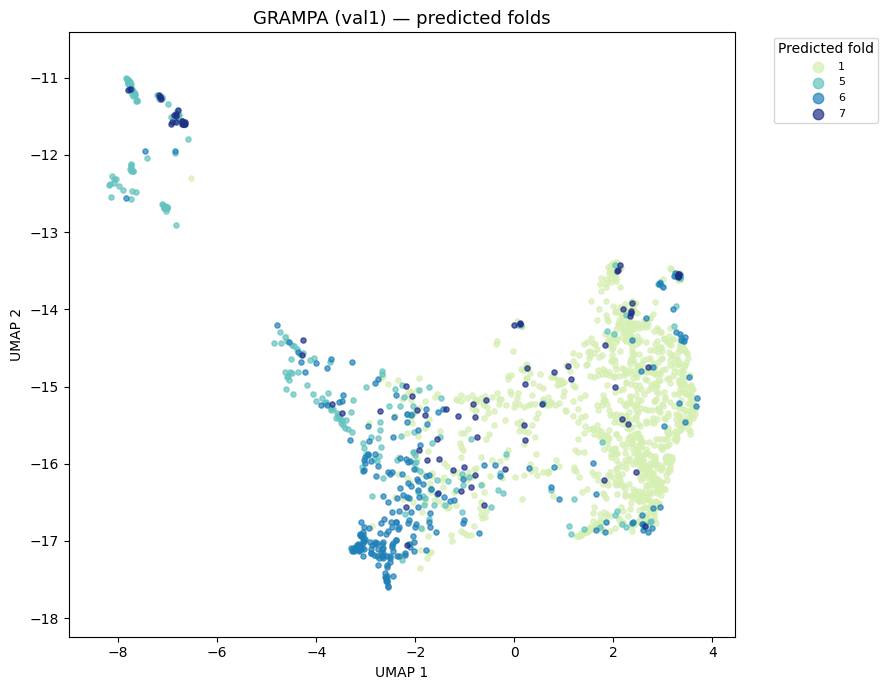

Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_val2_folds.png
Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_val2_folds.pdf


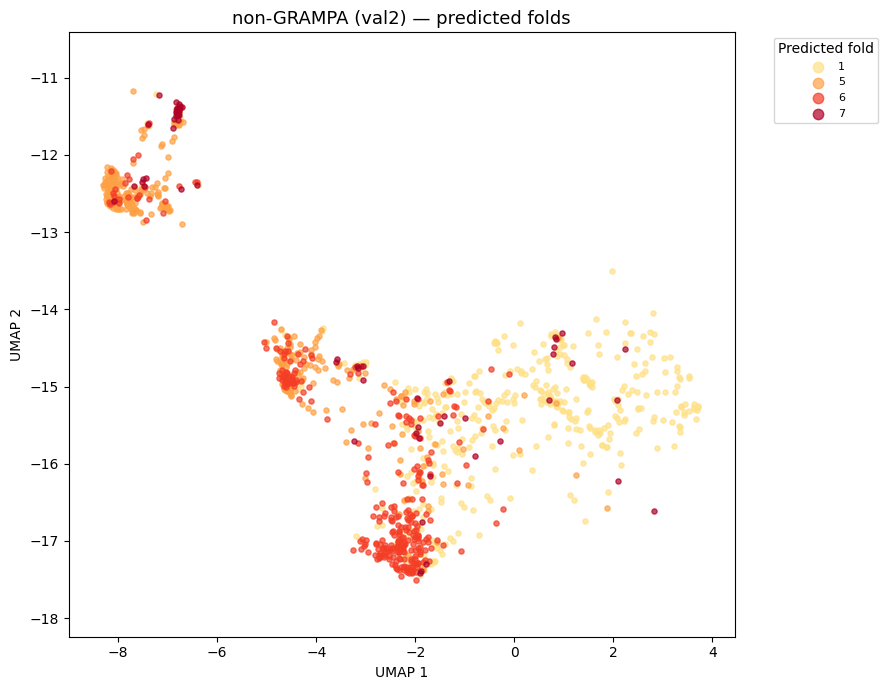

In [ ]:
# ── 10. Plot folds ─────────────────────────────────────────────────────────────

def plot_folds(proj, folds: pd.Series, cmap: str, title: str, fname: str):
    unique_folds   = sorted(folds.unique())
    colours        = plt.get_cmap(cmap)(np.linspace(0.2, 0.9, len(unique_folds)))
    fold_to_colour = dict(zip(unique_folds, colours))

    fig, ax = plt.subplots(figsize=(9, 7))
    for fold in unique_folds:
        mask = folds.values == fold
        ax.scatter(*proj[mask].T, s=14, alpha=0.7,
                   color=fold_to_colour[fold], label=fold)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xlim(x_lim); ax.set_ylim(y_lim)
    ax.legend(title="Predicted fold", bbox_to_anchor=(1.05, 1),
              loc="upper left", markerscale=2, fontsize=8)
    plt.tight_layout()
    for ext in ["png", "pdf"]:
        path = fname.rsplit(".", 1)[0] + f".{ext}"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved → {path}")
    plt.show()

FIG = "/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures"

plot_folds(val1_proj, val1_folds, cmap="YlGnBu",
           title="GRAMPA (val1) — predicted folds",
           fname=f"{FIG}/umap_val1_folds.png")
plot_folds(val2_proj, val2_folds, cmap="YlOrRd",
           title="non-GRAMPA (val2) — predicted folds",
           fname=f"{FIG}/umap_val2_folds.png")

Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_pepnet_train1_grampa.png
Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_pepnet_train1_grampa.pdf


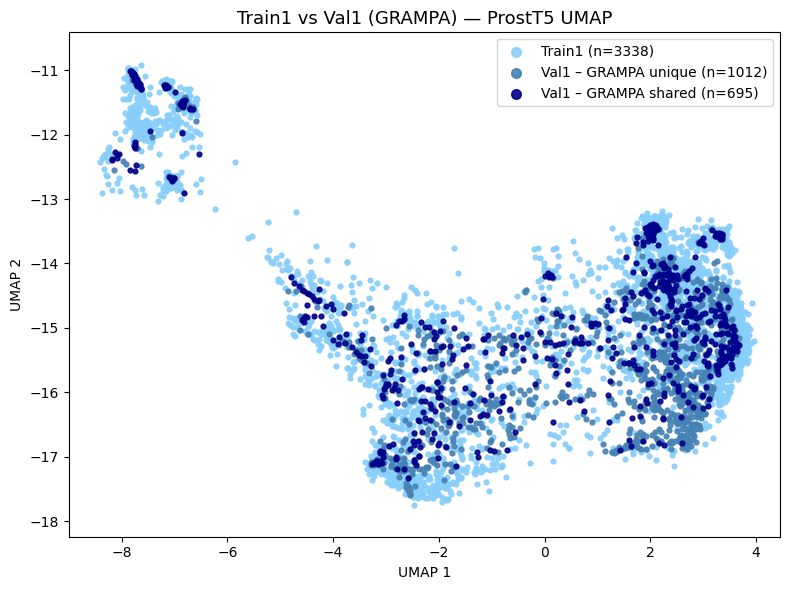

Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_pepnet_train2_non_grampa.png
Saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_pepnet_train2_non_grampa.pdf


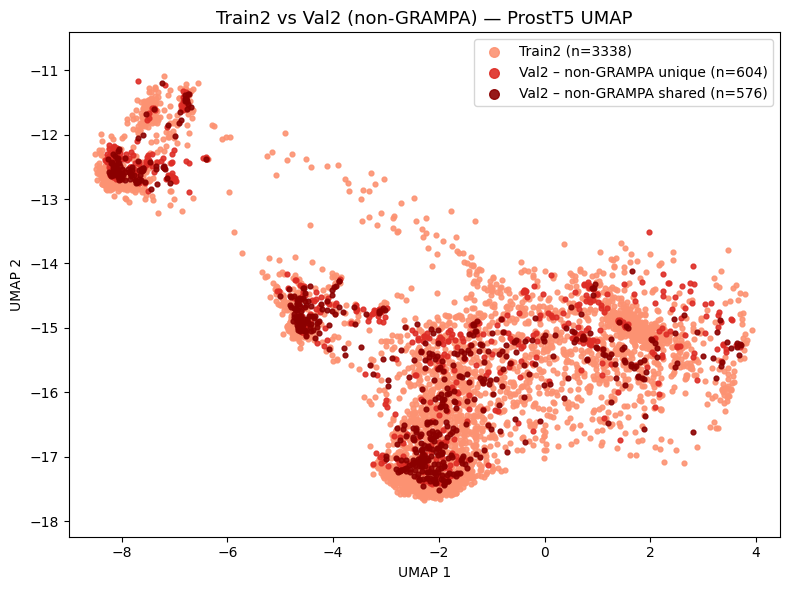

In [ ]:
# ── 11. Plot train vs val + leakage ───────────────────────────────────────────

SCHEME = {
    1: dict(train="lightskyblue", val="steelblue", shared="darkblue", label="GRAMPA"),
    2: dict(train="#fc9272",      val="#de2d26",    shared="darkred",  label="non-GRAMPA"),
}

def plot_umap(train_proj, val_proj, val_ids, shared_ids, scheme, fname):
    is_shared = np.array([vid in shared_ids for vid in val_ids])
    c         = SCHEME[scheme]
    val_label = c["label"]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(*train_proj.T, s=12, alpha=0.9, color=c["train"],
               label=f"Train{scheme} (n={len(train_proj)})")
    ax.scatter(*val_proj[~is_shared].T, s=12, alpha=0.9, color=c["val"],
               label=f"Val{scheme} – {val_label} unique (n={(~is_shared).sum()})")
    ax.scatter(*val_proj[is_shared].T,  s=12, alpha=0.9, color=c["shared"],
               label=f"Val{scheme} – {val_label} shared (n={is_shared.sum()})",
               zorder=5)
    ax.set_title(f"Train{scheme} vs Val{scheme} ({val_label}) — ProstT5 UMAP", fontsize=13)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xlim(x_lim); ax.set_ylim(y_lim)
    ax.legend(markerscale=2)
    plt.tight_layout()
    for ext in ["png", "pdf"]:
        path = fname.rsplit(".", 1)[0] + f".{ext}"
        plt.savefig(path, dpi=150)
        print(f"Saved → {path}")
    plt.show()

FIG = "/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures"

plot_umap(train1_proj, val1_proj, val1_ids, shared1, scheme=1,
          fname=f"{FIG}/umap_pepnet_train1_grampa.png")
plot_umap(train2_proj, val2_proj, val2_ids, shared2, scheme=2,
          fname=f"{FIG}/umap_pepnet_train2_non_grampa.png")

**Conclusions**

1. ProstT5 encodes fold information, but weakly
A peak silhouette score of 0.25 indicates modest separation. The embeddings carry a genuine fold signal, but folds 1, 5, 6, and 7 occupy broadly overlapping regions in embedding space rather than discrete clusters. This is biologically plausible — short peptides are structurally plastic and fold boundaries are not sharp.
2. The fold signal is global and non-linear
The monotonic improvement of silhouette score with n_neighbors up to n - 1 reveals that fold identity is distributed across the entire embedding manifold, not encoded in local neighbourhoods. The fact that UMAP at n - 1 still outperforms PCA (~0.25 vs ~0.20) confirms the signal is real but non-linear — neither a clustering method nor a linear projection alone would have revealed it.
3. UMAP is being pushed beyond its intended use case
UMAP is designed to preserve local structure. When optimal performance requires n_neighbors = n - 1, you are effectively asking UMAP to behave as a global manifold method — which it was not designed for. It works here, but the parameter regime is unusual and the result should be interpreted cautiously.
4. ProstT5 + UMAP is better suited for distribution visualisation than fold discovery
The original goal of comparing training and validation set coverage is well served by this approach — UMAP faithfully maps the sequence-structure landscape and highlights leakage and distributional gaps. However, as a tool for fold discrimination specifically, the weak silhouette scores suggest ProstT5 mean-pooled embeddings may not capture enough structural resolution to cleanly separate folds in 2D.
5. Potential improvements worth exploring

Residue-level embeddings instead of mean pooling — fold-discriminative signal may be buried in positional patterns that averaging destroys
ProstT5 in structure mode (<fold2AA>) using predicted 3Di tokens as input, which may encode fold geometry more directly than sequence embeddings
Supervised dimensionality reduction (e.g. LDA or UMAP with target_metric) using fold labels to guide the projection
Dedicated structural classifiers (e.g. Foldseek-based clustering) may simply be more appropriate than embedding-based visualisation for fold separation in short peptides

In short, ProstT5 + UMAP is a powerful distribution visualisation tool for this dataset, but the pairing reaches its limits when asked to cleanly separate structural folds in the peptide space.

**Data Leakage and Predictions**

In [7]:
# ── 1. Load datasets ───────────────────────────────────
def load_fasta(path):
    return {rec.id: str(rec.seq).upper() for rec in SeqIO.parse(path, "fasta")}

amplify_pos_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amplify_balanced_train_pos.fasta")
amplify_neg_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/amplify_balanced_train_neg.fasta")

pepnet_pos_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/pepnet_train_pos.fasta")
pepnet_neg_seqs = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/train/pepnet_train_neg.fasta")

grampa_seqs    = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/validation/grampa_cdhit.fasta")
non_grampa_seqs    = load_fasta("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/validation/non-grampa_cdhit.fasta")

In [8]:
# ── 2. Identify exact matches (train vs val) ───────────────────────────────────

def find_shared(train: dict, val: dict) -> set:
    """Returns val IDs whose sequence appears verbatim in train."""
    train_seqset = set(train.values())
    return {vid for vid, vseq in val.items() if vseq in train_seqset}

shared1 = find_shared(amplify_pos_seqs, grampa_seqs)
shared2 = find_shared(amplify_neg_seqs, non_grampa_seqs)
shared3 = find_shared(pepnet_pos_seqs, grampa_seqs)
shared4 = find_shared(pepnet_neg_seqs, non_grampa_seqs)

print(f"GRAMPA sequences shared with AMPlify:     {len(shared1)}/{len(grampa_seqs)}")
print(f"non-GRAMPA sequences shared with AMPlify: {len(shared2)}/{len(non_grampa_seqs)}")
print(f"GRAMPA sequences shared with PepNet:     {len(shared3)}/{len(grampa_seqs)}")
print(f"non-GRAMPA sequences shared with PepNet: {len(shared4)}/{len(non_grampa_seqs)}")

GRAMPA sequences shared with AMPlify:     703/1731
non-GRAMPA sequences shared with AMPlify: 579/1185
GRAMPA sequences shared with PepNet:     703/1731
non-GRAMPA sequences shared with PepNet: 579/1185


In [9]:
# ── 3. Load predictions  ───────────────────────────────────

grampa_amplify_preds = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/activity_predictions/GRAMPA_predicted_folds_&_activity_AMPlify.csv")
grampa_pepnet_preds = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/activity_predictions/GRAMPA_predicted_folds_&_activity_PepNet.csv")
non_grampa_amplify_preds = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/activity_predictions/Non_GRAMPA_predicted_folds_&_activity_AMPlify.csv")
non_grampa_pepnet_preds = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/activity_predictions/Non_GRAMPA_predicted_folds_&_activity_PepNet.csv")

In [14]:
# ── 4. Measure proportions per fold  ───────────────────────────────────

"""
amp_fold_metrics.py
-------------------
Compares observed vs. predicted antimicrobial peptide (AMP) classifications
grouped by cross-validation fold.

Metrics reported per fold
─────────────────────────
  TP  – True Positive  : Obs = AMP  &  Pred = AMP
  FN  – False Negative : Obs = AMP  &  Pred = non-AMP
  TN  – True Negative  : Obs = non-AMP  &  Pred = non-AMP   (bonus)
  FP  – False Positive : Obs = non-AMP  &  Pred = AMP       (bonus)

Proportions (%) are computed relative to the total number of samples in
each fold so that results are comparable across folds of different sizes.
"""

import pandas as pd


# ── label constants ──────────────────────────────────────────────────────────
AMP     = "AMP"
NON_AMP = "non-AMP"


def compute_fold_metrics(
    df: pd.DataFrame,
    obs_col:  str = "Obs_class",
    pred_col: str = "Pred_class",
    fold_col: str = "fold",
    amp_label:     str = AMP,
    non_amp_label: str = NON_AMP,
) -> pd.DataFrame:
    """
    Compute TP / FN (and FP / TN) counts and proportions per fold.

    Parameters
    ----------
    df            : DataFrame containing observations, predictions, and fold IDs.
    obs_col       : Column name for the observed (true) class label.
    pred_col      : Column name for the predicted class label.
    fold_col      : Column name for the fold identifier.
    amp_label     : String label that represents the positive class (AMP).
    non_amp_label : String label that represents the negative class (non-AMP).

    Returns
    -------
    pd.DataFrame with one row per fold and columns:
        Fold, Total, TP, FN, FP, TN,
        TP_pct, FN_pct, FP_pct, TN_pct
    """
    records = []

    for fold, group in df.groupby(fold_col, sort=True):
        obs  = group[obs_col]
        pred = group[pred_col]
        n    = len(group)

        tp = int(((obs == amp_label)     & (pred == amp_label)).sum())
        fn = int(((obs == amp_label)     & (pred == non_amp_label)).sum())
        fp = int(((obs == non_amp_label) & (pred == amp_label)).sum())
        tn = int(((obs == non_amp_label) & (pred == non_amp_label)).sum())

        records.append({
            "fold"   : fold,
            "Total"  : n,
            "TP"     : tp,
            "FN"     : fn,
            "FP"     : fp,
            "TN"     : tn,
            "TP_pct" : round(tp / n * 100, 2),
            "FN_pct" : round(fn / n * 100, 2),
            "FP_pct" : round(fp / n * 100, 2),
            "TN_pct" : round(tn / n * 100, 2),
        })

    return pd.DataFrame(records).set_index("fold")

In [16]:
grampa_amplify = compute_fold_metrics(grampa_amplify_preds)
grampa_amplify

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,1119,1026,93,0,0,91.69,8.31,0.0,0.0
5,261,237,24,0,0,90.80,9.20,0.0,0.0
6,244,213,31,0,0,87.30,12.70,0.0,0.0
7,83,74,9,0,0,89.16,10.84,0.0,0.0


In [17]:
non_grampa_amplify = compute_fold_metrics(non_grampa_amplify_preds)
non_grampa_amplify

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,425,0,0,96,329,0.0,0.0,22.59,77.41
5,387,0,0,59,328,0.0,0.0,15.25,84.75
6,302,0,0,40,262,0.0,0.0,13.25,86.75
7,66,0,0,16,50,0.0,0.0,24.24,75.76


In [18]:
grampa_pepnet = compute_fold_metrics(grampa_pepnet_preds)
grampa_pepnet

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,1119,1009,110,0,0,90.17,9.83,0.0,0.0
5,261,234,27,0,0,89.66,10.34,0.0,0.0
6,244,199,45,0,0,81.56,18.44,0.0,0.0
7,83,73,10,0,0,87.95,12.05,0.0,0.0


In [19]:
non_grampa_pepnet = compute_fold_metrics(non_grampa_pepnet_preds)
non_grampa_pepnet

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,425,0,0,119,306,0.0,0.0,28.00,72.00
5,387,0,0,72,315,0.0,0.0,18.60,81.40
6,302,0,0,50,252,0.0,0.0,16.56,83.44
7,66,0,0,20,46,0.0,0.0,30.30,69.70


In [21]:
# ── 5. Repeat the predictions once shared sequences were removed  ───────────────────────────────────

grampa_amplify_preds_no_shared = grampa_amplify_preds[~grampa_amplify_preds["id"].isin(shared1)]
non_grampa_amplify_preds_no_shared = non_grampa_amplify_preds[~non_grampa_amplify_preds["id"].isin(shared2)]
grampa_pepnet_preds_no_shared = grampa_pepnet_preds[~grampa_pepnet_preds["id"].isin(shared3)]
non_grampa_pepnet_preds_no_shared = non_grampa_pepnet_preds[~non_grampa_pepnet_preds["id"].isin(shared4)]



In [22]:
grampa_amplify_no_shared = compute_fold_metrics(grampa_amplify_preds_no_shared)
grampa_amplify_no_shared

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,700,607,93,0,0,86.71,13.29,0.0,0.0
5,124,100,24,0,0,80.65,19.35,0.0,0.0
6,142,111,31,0,0,78.17,21.83,0.0,0.0
7,46,37,9,0,0,80.43,19.57,0.0,0.0


In [23]:
non_grampa_amplify_no_shared = compute_fold_metrics(non_grampa_amplify_preds_no_shared)
non_grampa_amplify_no_shared

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,238,0,0,93,145,0.0,0.0,39.08,60.92
5,209,0,0,59,150,0.0,0.0,28.23,71.77
6,113,0,0,40,73,0.0,0.0,35.40,64.60
7,44,0,0,16,28,0.0,0.0,36.36,63.64


In [26]:
grampa_pepnet_no_shared = compute_fold_metrics(grampa_pepnet_preds_no_shared)
grampa_pepnet_no_shared

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,700,596,104,0,0,85.14,14.86,0.0,0.0
5,124,98,26,0,0,79.03,20.97,0.0,0.0
6,142,100,42,0,0,70.42,29.58,0.0,0.0
7,46,36,10,0,0,78.26,21.74,0.0,0.0


In [24]:
non_grampa_pepnet_no_shared = compute_fold_metrics(non_grampa_pepnet_preds_no_shared)
non_grampa_pepnet_no_shared

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,238,0,0,107,131,0.0,0.0,44.96,55.04
5,209,0,0,67,142,0.0,0.0,32.06,67.94
6,113,0,0,50,63,0.0,0.0,44.25,55.75
7,44,0,0,19,25,0.0,0.0,43.18,56.82


**Combine results and compare proportions**

AMPlify



In [27]:
amplify_combined = pd.concat([grampa_amplify, non_grampa_amplify])
amplify_combined

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,1119,1026,93,0,0,91.69,8.31,0.00,0.00
5,261,237,24,0,0,90.80,9.20,0.00,0.00
6,244,213,31,0,0,87.30,12.70,0.00,0.00
7,83,74,9,0,0,89.16,10.84,0.00,0.00
1,425,0,0,96,329,0.00,0.00,22.59,77.41
5,387,0,0,59,328,0.00,0.00,15.25,84.75
6,302,0,0,40,262,0.00,0.00,13.25,86.75
7,66,0,0,16,50,0.00,0.00,24.24,75.76


In [28]:
amplify_combined_no_shared = pd.concat([grampa_amplify_no_shared, non_grampa_amplify_no_shared])
amplify_combined_no_shared

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,700,607,93,0,0,86.71,13.29,0.00,0.00
5,124,100,24,0,0,80.65,19.35,0.00,0.00
6,142,111,31,0,0,78.17,21.83,0.00,0.00
7,46,37,9,0,0,80.43,19.57,0.00,0.00
1,238,0,0,93,145,0.00,0.00,39.08,60.92
5,209,0,0,59,150,0.00,0.00,28.23,71.77
6,113,0,0,40,73,0.00,0.00,35.40,64.60
7,44,0,0,16,28,0.00,0.00,36.36,63.64


In [29]:
# Save results
amplify_combined.to_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/amplify_fold_metrics.csv")
amplify_combined_no_shared.to_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/amplify_fold_metrics_no_shared.csv")

PepNet

In [31]:
pepnet_combined = pd.concat([grampa_pepnet, non_grampa_pepnet])
pepnet_combined

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,1119,1009,110,0,0,90.17,9.83,0.00,0.00
5,261,234,27,0,0,89.66,10.34,0.00,0.00
6,244,199,45,0,0,81.56,18.44,0.00,0.00
7,83,73,10,0,0,87.95,12.05,0.00,0.00
1,425,0,0,119,306,0.00,0.00,28.00,72.00
5,387,0,0,72,315,0.00,0.00,18.60,81.40
6,302,0,0,50,252,0.00,0.00,16.56,83.44
7,66,0,0,20,46,0.00,0.00,30.30,69.70


In [32]:
pepnet_combined_no_shared = pd.concat([grampa_pepnet_no_shared, non_grampa_pepnet_no_shared])
pepnet_combined_no_shared

,Total,TP,FN,FP,TN,TP_pct,FN_pct,FP_pct,TN_pct
fold,,,,,,,,,
1,700,596,104,0,0,85.14,14.86,0.00,0.00
5,124,98,26,0,0,79.03,20.97,0.00,0.00
6,142,100,42,0,0,70.42,29.58,0.00,0.00
7,46,36,10,0,0,78.26,21.74,0.00,0.00
1,238,0,0,107,131,0.00,0.00,44.96,55.04
5,209,0,0,67,142,0.00,0.00,32.06,67.94
6,113,0,0,50,63,0.00,0.00,44.25,55.75
7,44,0,0,19,25,0.00,0.00,43.18,56.82


In [33]:
# Save results
pepnet_combined.to_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/pepnet_fold_metrics.csv")
pepnet_combined_no_shared.to_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/pepnet_fold_no_shared.csv")

Generate plots

In [1]:
import argparse
import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
# ── Colour palette ────────────────────────────────────────────────────────────
TP_C   = "#6a8bef"   # true positive
FN_C   = "#bbd1f8"   # false negative
FP_C   = "#f3c7b1"   # false positive
TN_C   = "#e36c55"   # true negative
MUTED  = "#6b6b6b"
RULE   = "#dddad5"
INK    = "#1a1a1a"
BG     = "#fafaf8"
HATCH  = "////"      # hatch pattern for "after" bars


In [3]:
# ── Data loading ──────────────────────────────────────────────────────────────

def load_csv(path: str) -> dict:
    """
    Read one fold-metrics CSV and return a dict with keys
    pos_before/pos_after/neg_before/neg_after, each containing
    arrays for TP_pct, FN_pct, FP_pct, TN_pct across 4 folds.

    Actually this function just returns the raw DataFrame;
    the split into pos/neg is done in load_data().
    """
    df = pd.read_csv(path)
    for col in ["Total", "TP", "FN", "FP", "TN"]:
        df[col] = df[col].astype(int)
    return df


def load_data(before_path: str, after_path: str) -> dict:
    """
    Return a nested dict:
      {
        'pos_before': {'TP': [...], 'FN': [...]},
        'pos_after':  {'TP': [...], 'FN': [...]},
        'neg_before': {'FP': [...], 'TN': [...]},
        'neg_after':  {'FP': [...], 'TN': [...]},
        'folds':      [1, 5, 6, 7],
      }
    """
    bf = load_csv(before_path)
    af = load_csv(after_path)

    pos_b = bf.iloc[:4].reset_index(drop=True)
    neg_b = bf.iloc[4:].reset_index(drop=True)
    pos_a = af.iloc[:4].reset_index(drop=True)
    neg_a = af.iloc[4:].reset_index(drop=True)

    return {
        "folds":      pos_b["fold"].tolist(),
        "pos_before": {"TP": pos_b["TP_pct"].tolist(), "FN": pos_b["FN_pct"].tolist()},
        "pos_after":  {"TP": pos_a["TP_pct"].tolist(), "FN": pos_a["FN_pct"].tolist()},
        "neg_before": {"FP": neg_b["FP_pct"].tolist(), "TN": neg_b["TN_pct"].tolist()},
        "neg_after":  {"FP": neg_a["FP_pct"].tolist(), "TN": neg_a["TN_pct"].tolist()},
    }


def compute_deltas(data: dict) -> dict:
    """Return ΔTP% and ΔFP% (after − before) for each fold."""
    tp_d = [data["pos_after"]["TP"][i] - data["pos_before"]["TP"][i] for i in range(4)]
    fp_d = [data["neg_after"]["FP"][i] - data["neg_before"]["FP"][i] for i in range(4)]
    return {"tp": tp_d, "fp": fp_d}

In [4]:
# ── Shared axis styling ───────────────────────────────────────────────────────

def style_ax(ax):
    ax.set_facecolor(BG)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(RULE)
    ax.spines["bottom"].set_color(RULE)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.grid(axis="y", color=RULE, linewidth=0.6, zorder=0)

In [13]:
import argparse
import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages


# ── Colour palette ────────────────────────────────────────────────────────────
TP_C   = "#6a8bef"   # true positive
FN_C   = "#bbd1f8"   # false negative
FP_C   = "#f3c7b1"   # false positive
TN_C   = "#e36c55"   # true negative
MUTED  = "#6b6b6b"
RULE   = "#dddad5"
INK    = "#1a1a1a"
BG     = "#fafaf8"
HATCH  = "////"      # hatch pattern for "after" bars


# ── Data loading ──────────────────────────────────────────────────────────────

def load_csv(path: str) -> dict:
    """
    Read one fold-metrics CSV and return a dict with keys
    pos_before/pos_after/neg_before/neg_after, each containing
    arrays for TP_pct, FN_pct, FP_pct, TN_pct across 4 folds.

    Actually this function just returns the raw DataFrame;
    the split into pos/neg is done in load_data().
    """
    df = pd.read_csv(path)
    for col in ["Total", "TP", "FN", "FP", "TN"]:
        df[col] = df[col].astype(int)
    return df


def load_data(before_path: str, after_path: str) -> dict:
    """
    Return a nested dict:
      {
        'pos_before': {'TP': [...], 'FN': [...]},
        'pos_after':  {'TP': [...], 'FN': [...]},
        'neg_before': {'FP': [...], 'TN': [...]},
        'neg_after':  {'FP': [...], 'TN': [...]},
        'folds':      [1, 5, 6, 7],
      }
    """
    bf = load_csv(before_path)
    af = load_csv(after_path)

    pos_b = bf.iloc[:4].reset_index(drop=True)
    neg_b = bf.iloc[4:].reset_index(drop=True)
    pos_a = af.iloc[:4].reset_index(drop=True)
    neg_a = af.iloc[4:].reset_index(drop=True)

    return {
        "folds":      pos_b["fold"].tolist(),
        "pos_before": {"TP": pos_b["TP_pct"].tolist(), "FN": pos_b["FN_pct"].tolist()},
        "pos_after":  {"TP": pos_a["TP_pct"].tolist(), "FN": pos_a["FN_pct"].tolist()},
        "neg_before": {"FP": neg_b["FP_pct"].tolist(), "TN": neg_b["TN_pct"].tolist()},
        "neg_after":  {"FP": neg_a["FP_pct"].tolist(), "TN": neg_a["TN_pct"].tolist()},
    }


def compute_deltas(data: dict) -> dict:
    """Return ΔTP% and ΔFP% (after − before) for each fold."""
    tp_d = [data["pos_after"]["TP"][i] - data["pos_before"]["TP"][i] for i in range(4)]
    fp_d = [data["neg_after"]["FP"][i] - data["neg_before"]["FP"][i] for i in range(4)]
    return {"tp": tp_d, "fp": fp_d}


# ── Shared axis styling ───────────────────────────────────────────────────────

def style_ax(ax):
    ax.set_facecolor(BG)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(RULE)
    ax.spines["bottom"].set_color(RULE)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.grid(axis="y", color=RULE, linewidth=0.6, zorder=0)


def draw_figure6(amp_data: dict, pep_data: dict, out_path: str) -> None:
    """
    Two-column, two-row layout.
    Column A = AMPlify, Column B = PepNet.
    Row 1 = Positive set (TP stacked on FN).
    Row 2 = Negative set (TN stacked on FP, y-axis inverted).
    Delta labels printed below each fold group.
    """
    fig = plt.figure(figsize=(14, 11), facecolor="white")
    fig.patch.set_facecolor("white")

    # Figure-level title and subtitle
    fig.text(
        0.5, 0.975,
        "Figure 6 \u2014 Classification Proportions Before and After Data Leakage Removal",
        ha="center", va="top", fontsize=11.5, color=INK,
        fontfamily="serif", fontweight="bold",
    )
    fig.text(
        0.5, 0.952,
        ("Solid bars = before leakage removal \u00b7 Hatched bars = after removal \u00b7 "
         "Positive set: TP\u202fstacked on FN \u00b7 Negative set: TN\u202fstacked on FP (inverted y-axis)"),
        ha="center", va="top", fontsize=8, color=MUTED,
        fontstyle="italic", fontfamily="serif",
    )

    gs = fig.add_gridspec(
        2, 2, hspace=0.22, wspace=0.12,
        left=0.07, right=0.97, top=0.91, bottom=0.12,
    )

    panels = [
        {"model": "AMPlify", "data": amp_data, "label": "(A) AMPlify"},
        {"model": "PepNet",  "data": pep_data, "label": "(B) PepNet"},
    ]

    bw   = 0.18               # bar width
    gap  = 0.03               # gap between before/after bars within a pair
    grp  = bw * 2 + gap       # total width of one fold group
    n    = 4
    xc    = np.arange(n) * 0.9  # fold group centres

    for ci, panel in enumerate(panels):
        D    = panel["data"]
        delt = compute_deltas(D)
        fold_labels = [f"Fold {f}" for f in D["folds"]]

        # ── Positive set ────────────────────────────────────────────────────
        ax_p = fig.add_subplot(gs[0, ci])
        style_ax(ax_p)

        for i, cx in enumerate(xc):
            x0 = cx - grp / 2

            # Before bars
            ax_p.bar(x0, D["pos_before"]["TP"][i], bw,
                     color=TP_C, zorder=3, linewidth=0)
            ax_p.bar(x0, D["pos_before"]["FN"][i], bw,
                     bottom=D["pos_before"]["TP"][i], color=FN_C, zorder=3, linewidth=0)

            # After bars (hatched)
            ax_p.bar(x0 + bw + gap, D["pos_after"]["TP"][i], bw,
                     color=TP_C, hatch=HATCH, edgecolor="white", linewidth=0, zorder=3)
            ax_p.bar(x0 + bw + gap, D["pos_after"]["FN"][i], bw,
                     bottom=D["pos_after"]["TP"][i],
                     color=FN_C, hatch=HATCH, edgecolor="white", linewidth=0, zorder=3)

            # ΔTP% label below the group
            mid = x0 + bw + gap / 2
            d   = delt["tp"][i]
            ax_p.text(
                mid, -6.5, f"\u0394TP%={d:+.1f}",
                ha="center", va="top", fontsize=7,
                color=TN_C if d < 0 else TP_C,
                fontfamily="monospace", clip_on=False,
            )

        ax_p.set_xticks(xc)
        ax_p.set_xticklabels(fold_labels, fontsize=8.5, color=INK)
        ax_p.set_ylim(0, 108)
        ax_p.set_xlim(xc[0] - 0.35, xc[-1] + 0.35)
        ax_p.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g%%"))
        ax_p.set_ylabel("Proportion (%)", fontsize=9, color=MUTED)
        ax_p.set_title(
            f"{panel['label']} \u2014 Positive Set (AMP / GRAMPA)",
            fontsize=10, color=INK, pad=10,
            fontfamily="serif", fontweight="semibold",
        )

        # ── Negative set (inverted y) ────────────────────────────────────────
        ax_n = fig.add_subplot(gs[1, ci])
        style_ax(ax_n)

        for i, cx in enumerate(xc):
            x0 = cx - grp / 2

            # Before bars: TN at base, FP stacked above
            ax_n.bar(x0, D["neg_before"]["TN"][i], bw,
                     color=TN_C, zorder=3, linewidth=0)
            ax_n.bar(x0, D["neg_before"]["FP"][i], bw,
                     bottom=D["neg_before"]["TN"][i], color=FP_C, zorder=3, linewidth=0)

            # After bars (hatched)
            ax_n.bar(x0 + bw + gap, D["neg_after"]["TN"][i], bw,
                     color=TN_C, hatch=HATCH, edgecolor="white", linewidth=0, zorder=3)
            ax_n.bar(x0 + bw + gap, D["neg_after"]["FP"][i], bw,
                     bottom=D["neg_after"]["TN"][i],
                     color=FP_C, hatch=HATCH, edgecolor="white", linewidth=0, zorder=3)

            # ΔFP% label (placed at y=103 which appears at the visual bottom
            # after inversion)
            mid = x0 + bw + gap / 2
            d   = delt["fp"][i]
            ax_n.text(
                mid, 103, f"\u0394FP%={d:+.1f}",
                ha="center", va="bottom", fontsize=7,
                color=TN_C if d > 0 else TP_C,
                fontfamily="monospace", clip_on=False,
            )

        ax_n.invert_yaxis()
        ax_n.set_ylim(108, 0)
        ax_n.set_xticks(xc)
        ax_n.set_xticklabels(fold_labels, fontsize=8.5, color=INK)
        ax_n.set_xlim(xc[0] - 0.35, xc[-1] + 0.35)
        ax_n.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g%%"))
        ax_n.set_ylabel("Proportion (%, inverted)", fontsize=9, color=MUTED)
        ax_n.set_title(
            f"{panel['label']} \u2014 Negative Set (non-AMP / non-GRAMPA)",
            fontsize=10, color=INK, pad=10,
            fontfamily="serif", fontweight="semibold",
        )

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor=TP_C, label="TP (True Positive)"),
        mpatches.Patch(facecolor=FN_C, label="FN (False Negative)"),
        mpatches.Patch(facecolor=FP_C, label="FP (False Positive)"),
        mpatches.Patch(facecolor=TN_C, label="TN (True Negative)"),
        mpatches.Patch(facecolor="#cccccc", label="Before leakage removal"),
        mpatches.Patch(facecolor="#cccccc", hatch=HATCH, edgecolor="white",
                       label="After leakage removal"),
    ]
    fig.legend(
        handles=legend_elements, loc="lower center", ncol=6,
        fontsize=8, frameon=True, framealpha=0.95,
        edgecolor=RULE, facecolor="white",
        bbox_to_anchor=(0.5, 0.01),
    )

    # ── Save ──────────────────────────────────────────────────────────────────
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, bbox_inches="tight", facecolor="white", dpi=300)
        info = pdf.infodict()
        info["Title"]   = "Figure 6 – AMP Classification Proportions"
        info["Subject"] = "Before and after data leakage removal"
    plt.close(fig)
    print(f"  Figure 6 saved \u2192 {out_path}")



# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4
# ════════════════════════════════════════════════════════════════════════════

def draw_figures5(amp_data: dict, pep_data: dict, out_path: str) -> None:
    """
    Two side-by-side heatmaps (Sensitivity TP% | FP rate FP%).
    Rows: AMPlify Before / After / Δ \u00b7 PepNet Before / After / Δ.
    Columns: one per fold.
    Δ rows use a diverging blue\u2192white\u2192red colour scale.
    """
    # ── Build row definitions ─────────────────────────────────────────────────
    def make_rows(data: dict, model_name: str):
        tp_d = [data["pos_after"]["TP"][i] - data["pos_before"]["TP"][i] for i in range(4)]
        fp_d = [data["neg_after"]["FP"][i] - data["neg_before"]["FP"][i] for i in range(4)]
        return [
            {"label": f"{model_name} \u00b7 Before",
             "tp": data["pos_before"]["TP"], "fp": data["neg_before"]["FP"],
             "is_delta": False},
            {"label": f"{model_name} \u00b7 After",
             "tp": data["pos_after"]["TP"],  "fp": data["neg_after"]["FP"],
             "is_delta": False},
            {"label": f"{model_name} \u00b7 \u0394",
             "tp": tp_d, "fp": fp_d,
             "is_delta": True},
        ]

    rows = make_rows(amp_data, "AMPlify") + make_rows(pep_data, "PepNet")
    n_rows = len(rows)           # 6
    n_cols = 4                   # folds

    folds = amp_data["folds"]
    fold_labels = [f"Fold {f}" for f in folds]

    # ── Colour scales ─────────────────────────────────────────────────────────
    tp_cmap   = mcolors.LinearSegmentedColormap.from_list("tp", ["#dce8ff", TP_C])
    fp_cmap   = mcolors.LinearSegmentedColormap.from_list("fp", ["#fdeee9", TN_C])
    delta_cmap = mcolors.LinearSegmentedColormap.from_list(
        "delta", [TP_C, "#f5f5f0", TN_C]
    )

    tp_norm    = mcolors.Normalize(vmin=65, vmax=100)
    fp_norm    = mcolors.Normalize(vmin=0,  vmax=52)
    delta_norm = mcolors.TwoSlopeNorm(vmin=-14, vcenter=0, vmax=30)

    def cell_color(value, is_delta, metric):
        if is_delta:
            return delta_cmap(delta_norm(value))
        if metric == "tp":
            return tp_cmap(tp_norm(value))
        return fp_cmap(fp_norm(value))

    def text_color(value, is_delta, metric):
        if is_delta:
            return INK
        if metric == "tp":
            return "white" if value > 83 else INK
        return "white" if value > 30 else INK

    # ── Layout ────────────────────────────────────────────────────────────────
    fig_w = 13
    row_h = 0.62          # inches per heatmap row
    pad_t = 2.2           # top padding (titles, column headers)
    pad_b = 1.8           # bottom padding (legend, colorbars)
    fig_h = pad_t + n_rows * row_h + pad_b

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
    fig.patch.set_facecolor("white")
    ax.set_visible(False)   # We draw manually using figure coordinates

    # Convert inches \u2192 figure fractions
    def fy(inches_from_bottom):
        return inches_from_bottom / fig_h

    def fx(inches_from_left):
        return inches_from_left / fig_w

    # Geometry (in inches)
    left_label_w = 2.2
    hm_gap       = 0.55   # gap between the two heatmaps
    right_margin = 0.3
    col_bar_w    = 0.22
    n_colbars    = 2
    colbar_gap   = 0.15
    avail_w = (fig_w - left_label_w - hm_gap - right_margin
               - n_colbars * col_bar_w - (n_colbars - 1) * colbar_gap)
    hm_w    = avail_w / 2   # width of each heatmap block

    cell_w  = hm_w / n_cols
    cell_h  = row_h

    top_pad_in    = 1.8     # space above heatmap for titles & col headers
    bottom_pad_in = 1.5

    # Figure-level title
    fig.text(
        0.5, 1 - 0.12 / fig_h,
        "Figure S5 \u2014 Performance Heatmap: Sensitivity (TP%) and False Positive Rate (FP%)",
        ha="center", va="top", fontsize=11.5, color=INK,
        fontfamily="serif", fontweight="bold",
    )
    fig.text(
        0.5, 1 - 0.42 / fig_h,
        ("Stratified by model and leakage condition across all four folds. "
         "\u0394 rows show the absolute change attributable to leakage removal."),
        ha="center", va="top", fontsize=8.5, color=MUTED,
        fontstyle="italic", fontfamily="serif",
    )

    # x origins of the two heatmap blocks (in inches from left)
    hm_x0 = [left_label_w, left_label_w + hm_w + hm_gap]

    # y origin of the top-left cell (in inches from bottom)
    hm_y_top_in = bottom_pad_in + n_rows * row_h   # top edge of first row

    # ── Draw cells ────────────────────────────────────────────────────────────
    for ri, row in enumerate(rows):
        # y position: rows drawn top-to-bottom
        y_in = hm_y_top_in - (ri + 1) * cell_h   # bottom of this row in inches

        for metric_idx, (metric, values) in enumerate([("tp", row["tp"]),
                                                        ("fp", row["fp"])]):
            hx0 = hm_x0[metric_idx]
            for ci, val in enumerate(values):
                x_in  = hx0 + ci * cell_w
                fc    = cell_color(val, row["is_delta"], metric)
                tc    = text_color(val, row["is_delta"], metric)
                label = (f"{val:+.1f}" if row["is_delta"] else f"{val:.1f}")

                rect = plt.Rectangle(
                    [fx(x_in), fy(y_in)],
                    fx(cell_w) - 0.002,
                    fy(cell_h) - 0.004,
                    transform=fig.transFigure,
                    facecolor=fc, edgecolor="white", linewidth=0.8,
                    clip_on=False,
                )
                fig.add_artist(rect)

                fig.text(
                    fx(x_in + cell_w / 2),
                    fy(y_in + cell_h / 2),
                    label,
                    ha="center", va="center",
                    fontsize=9, color=tc,
                    fontfamily="monospace", fontweight="bold" if row["is_delta"] else "normal",
                    transform=fig.transFigure,
                )

        # Row label (left side)
        fig.text(
            fx(left_label_w - 0.08),
            fy(y_in + cell_h / 2),
            row["label"],
            ha="right", va="center",
            fontsize=9, color=MUTED if row["is_delta"] else INK,
            fontstyle="italic" if row["is_delta"] else "normal",
            fontfamily="monospace" if row["is_delta"] else "serif",
            transform=fig.transFigure,
        )

        # Separator line after each Δ row
        if row["is_delta"]:
            line_y = fy(y_in - 0.02)
            fig.add_artist(plt.Line2D(
                [fx(0.04), fx(fig_w - 0.1)],
                [line_y, line_y],
                transform=fig.transFigure,
                color=RULE, linewidth=1.4, clip_on=False,
            ))

    # ── Column headers & panel titles ─────────────────────────────────────────
    hm_panel_titles = ["Sensitivity (TP%)", "False Positive Rate (FP%)"]
    col_header_y_in = hm_y_top_in + 0.22
    panel_title_y_in = hm_y_top_in + 0.62

    for metric_idx in range(2):
        hx0 = hm_x0[metric_idx]
        # Panel title
        fig.text(
            fx(hx0 + hm_w / 2),
            fy(panel_title_y_in),
            hm_panel_titles[metric_idx],
            ha="center", va="bottom",
            fontsize=11, color=INK, fontweight="bold",
            fontfamily="serif", transform=fig.transFigure,
        )
        # Column (fold) headers
        for ci, fl in enumerate(fold_labels):
            fig.text(
                fx(hx0 + ci * cell_w + cell_w / 2),
                fy(col_header_y_in),
                fl,
                ha="center", va="bottom",
                fontsize=8.5, color=MUTED,
                fontfamily="monospace", transform=fig.transFigure,
            )

    # ── Colour-bar legends ────────────────────────────────────────────────────
    cb_x0_in = left_label_w + 2 * hm_w + hm_gap + 0.25
    cb_configs = [
        {"cmap": tp_cmap,  "norm": tp_norm,    "label": "TP%",
         "ticks": [65, 75, 85, 95, 100]},
        {"cmap": fp_cmap,  "norm": fp_norm,    "label": "FP%",
         "ticks": [0, 15, 30, 45, 52]},
    ]
    cb_h_in = n_rows * row_h

    for k, cfg in enumerate(cb_configs):
        x_in = cb_x0_in + k * (col_bar_w + colbar_gap)
        cb_ax = fig.add_axes([
            fx(x_in),
            fy(bottom_pad_in),
            fx(col_bar_w - 0.05),
            fy(cb_h_in),
        ])
        sm = plt.cm.ScalarMappable(cmap=cfg["cmap"], norm=cfg["norm"])
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cb_ax, ticks=cfg["ticks"])
        cb.ax.tick_params(labelsize=7, colors=MUTED)
        cb.set_label(cfg["label"], fontsize=9, color=INK, fontfamily="monospace")
        cb.outline.set_edgecolor(RULE)

    # Delta colorbar
    delta_ax = fig.add_axes([
        fx(cb_x0_in),
        fy(bottom_pad_in * 0.22),
        fx(2 * col_bar_w + colbar_gap - 0.05),
        fy(bottom_pad_in * 0.45),
    ])
    sm_d = plt.cm.ScalarMappable(cmap=delta_cmap, norm=delta_norm)
    sm_d.set_array([])
    cb_d = fig.colorbar(sm_d, cax=delta_ax, orientation="horizontal",
                        ticks=[-14, -7, 0, 10, 20, 30])
    cb_d.ax.tick_params(labelsize=7, colors=MUTED)
    cb_d.set_label("\u0394 (pp)", fontsize=9, color=INK,
                   fontfamily="monospace")
    cb_d.outline.set_edgecolor(RULE)

    # ── Save ──────────────────────────────────────────────────────────────────
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, bbox_inches="tight", facecolor="white", dpi=300)
        info = pdf.infodict()
        info["Title"]   = "Figure S5 – Performance Heatmap"
        info["Subject"] = "Sensitivity and FP rate before/after leakage removal"
    plt.close(fig)
    print(f"  Figure 7 saved \u2192 {out_path}")


# ── CLI ───────────────────────────────────────────────────────────────────────

def parse_args():
    p = argparse.ArgumentParser(
        description="Generate Figure 6 and Figure S5 for the AMPlify/PepNet leakage analysis."
    )
    p.add_argument("--amplify_before", required=True,
                   help="CSV: AMPlify metrics (with data leakage)")
    p.add_argument("--amplify_after",  required=True,
                   help="CSV: AMPlify metrics (leakage removed)")
    p.add_argument("--pepnet_before",  required=True,
                   help="CSV: PepNet metrics (with data leakage)")
    p.add_argument("--pepnet_after",   required=True,
                   help="CSV: PepNet metrics (leakage removed)")
    p.add_argument("--out_dir", default=".",
                   help="Output directory for PDF files (default: current directory)")

    # In a Colab environment, command-line arguments are not passed directly.
    # We define them here with paths to the previously saved results.
    args = p.parse_args([
        '--amplify_before', '/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/amplify_fold_metrics.csv',
        '--amplify_after', '/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/amplify_fold_metrics_no_shared.csv',
        '--pepnet_before', '/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/pepnet_fold_metrics.csv',
        '--pepnet_after', '/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/pepnet_fold_no_shared.csv',
        '--out_dir', '/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures'
    ])
    return args


def main():
    args = parse_args()

    # Validate input files
    for attr, path in [
        ("amplify_before", args.amplify_before),
        ("amplify_after",  args.amplify_after),
        ("pepnet_before",  args.pepnet_before),
        ("pepnet_after",   args.pepnet_after),
    ]:
        if not os.path.isfile(path):
            print(f"ERROR: file not found: {path}", file=sys.stderr)
            sys.exit(1)

    os.makedirs(args.out_dir, exist_ok=True)

    print("Loading data ...")
    amp_data = load_data(args.amplify_before, args.amplify_after)
    pep_data = load_data(args.pepnet_before,  args.pepnet_after)

    print("Rendering figures ...")
    draw_figure6(
        amp_data, pep_data,
        out_path=os.path.join(args.out_dir, "figure_6.pdf"),
    )
    draw_figures5(
        amp_data, pep_data,
        out_path=os.path.join(args.out_dir, "figure_S5.pdf"),
    )

    print("Done.")


if __name__ == "__main__":
    main()

Loading data ...
Rendering figures ...
  Figure 6 saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/figure_6.pdf
  Figure 7 saved → /content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/figure_S5.pdf
Done.


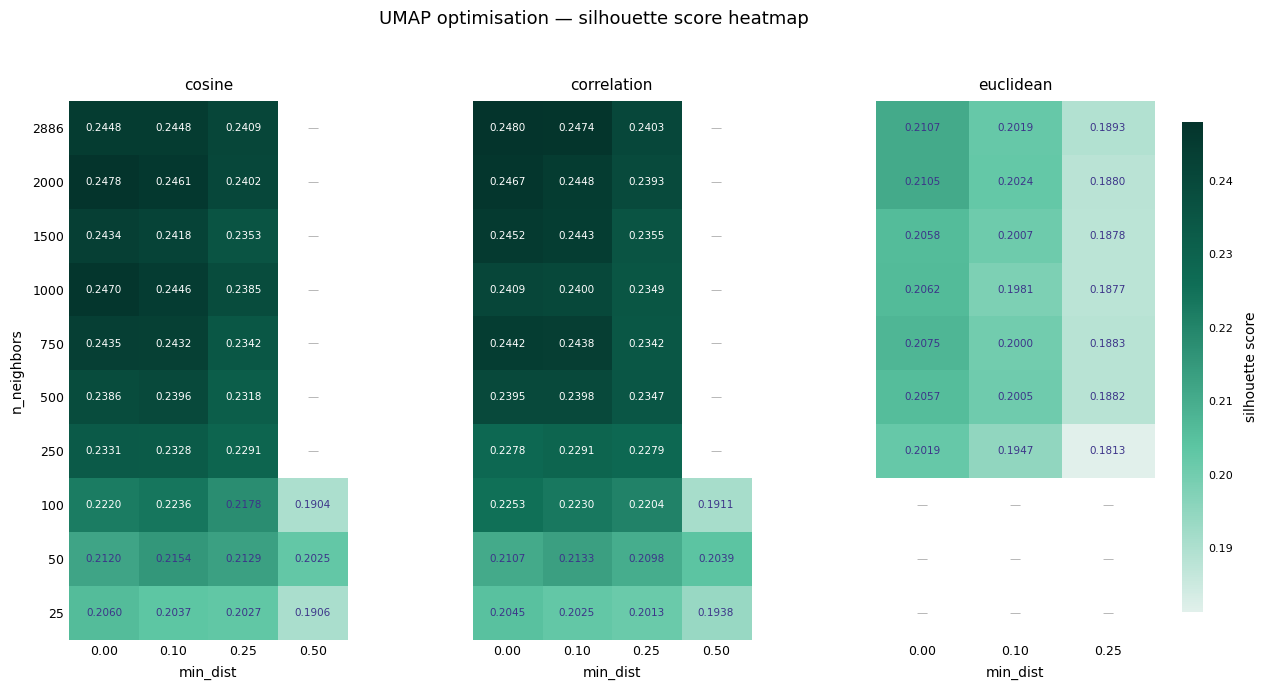

Saved: umap_silhouette_heatmap.pdf


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/results/complete_umap_optimisation_df2.csv")

metrics   = ["cosine", "correlation", "euclidean"]
all_n     = [25, 50, 100, 250, 500, 750, 1000, 1500, 2000, 2886]
n_labels  = ["25", "50", "100", "250", "500", "750", "1000", "1500", "2000", "2886"]
all_d     = [0.00, 0.10, 0.25, 0.50]

global_min = df["silhouette"].min()
global_max = df["silhouette"].max()

cmap = mcolors.LinearSegmentedColormap.from_list(
    "teal_ramp",
    [
        (225/255, 240/255, 235/255),
        ( 93/255, 198/255, 163/255),
        ( 15/255, 110/255,  86/255),
        (  4/255,  52/255,  44/255),
    ]
)
norm = mcolors.Normalize(vmin=global_min, vmax=global_max)

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 7),
    gridspec_kw={"wspace": 0.45}
)

for ax, metric in zip(axes, metrics):
    sub = df[df["metric"] == metric]
    d_vals = sorted(sub["min_dist"].unique())

    grid = np.full((len(all_n), len(d_vals)), np.nan)
    for i, n in enumerate(all_n):
        for j, d in enumerate(d_vals):
            row = sub[(sub["n_neighbors"] == n) & (sub["min_dist"] == d)]
            if not row.empty:
                grid[i, j] = row["silhouette"].values[0]

    grid_plot = grid[::-1, :]

    im = ax.imshow(
        grid_plot,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    for i in range(grid_plot.shape[0]):
        for j in range(grid_plot.shape[1]):
            val = grid_plot[i, j]
            if not np.isnan(val):
                t = (val - global_min) / (global_max - global_min)
                txt_color = "white" if t > 0.55 else "#3C3489"
                ax.text(
                    j, i, f"{val:.4f}",
                    ha="center", va="center",
                    fontsize=7.5, color=txt_color, fontweight="medium"
                )
            else:
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=8, color="#aaa")

    ax.set_xticks(range(len(d_vals)))
    ax.set_xticklabels([f"{d:.2f}" for d in d_vals], fontsize=9)
    ax.set_xlabel("min_dist", fontsize=10, labelpad=6)

    ax.set_yticks(range(len(all_n)))
    ax.set_yticklabels(n_labels[::-1], fontsize=9)
    if metric == metrics[0]:
        ax.set_ylabel("n_neighbors", fontsize=10, labelpad=6)
    else:
        ax.set_yticklabels([])

    ax.set_title(metric, fontsize=11, fontweight="medium", pad=8)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("silhouette score", fontsize=10, labelpad=8)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=8, length=0)

fig.suptitle(
    "UMAP optimisation — silhouette score heatmap",
    fontsize=13, fontweight="medium", y=1.01
)

plt.savefig("/content/drive/MyDrive/Colab Notebooks/AMPs_datasets/figures/umap_silhouette_heatmap.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: umap_silhouette_heatmap.pdf")